In [1]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    print("directory path is not in the system path")
    sys.path.append(str(dir))
    print("adding directory...")
else:
    print("Directory already exists in the system path")

Failed to read module file 'C:\Users\User\anaconda3\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\CodingHenry\research_MBKM\venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\CodingHenry\research_MBKM\venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and_load_unlocked
ModuleNotFoundE

directory path is not in the system path
adding directory...


In [2]:
from nn import Unet1D, Returns, RMSELoss, EarlyStopping
from scripts import train, evaluate
from utils import log_transform
import torch
from torch.utils.data import DataLoader
import yfinance as yf
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [3]:
ticker = "^GSPC"
start_interval = "2010-01-01"
end_interval = "2026-01-01"
interval = "1d"

raw_snp500 = torch.tensor(yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy())

In [4]:
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2
test_split = len(raw_snp500) - split
train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

window_size = 128

train_data = Returns(
  raw_returns=train_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
val_data = Returns(
  raw_returns=val_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
test_data = Returns(
  raw_returns=test_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)

len(train_data), len(val_data), len(test_data)

(2286, 677, 677)

In [5]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True, drop_last=True)

next(iter(train_dataloader)).size()

torch.Size([32, 1, 128])

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [7]:
betas = torch.linspace(1e-4, 2e-2, 1000)
encoder_in_channels = [1, 4, 8, 16]
encoder_out_channels = [4, 8, 16, 32]
decoder_in_channels = [32, 16, 8, 4]
decoder_out_channels = [16, 8, 4, 1]
attn_res = 16
n_res_block = 2
T = 1000
num_heads = 4
betas = torch.linspace(1e-4, 2e-2, T)
alpha_hats = torch.cumprod(
  input=1-betas,
  dim=0,
  dtype=torch.float32
)

model = Unet1D(
  attn_res=attn_res,
  n_res_block=n_res_block,
  encoder_in_channels=encoder_in_channels,
  encoder_out_channels=encoder_out_channels,
  decoder_in_channels=decoder_in_channels,
  decoder_out_channels=decoder_out_channels,
  T=T,
  num_heads=num_heads
)

In [8]:
dir = Path().resolve().parents[1]
save_path = dir / "models"

In [9]:
loss_fn = RMSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
  optimizer=optimizer,
  mode='min',
  factor=0.4,
  patience=2,
  threshold=1e-4
)

early_stop = EarlyStopping(
  model=model,
  save_path=save_path,
  patience=10,
  delta=0,
  file_name="model_128.pth",
  verbose=True
)

In [10]:
train_result = train(
  train_data=train_dataloader,
  val_data=val_dataloader,
  optimizer=optimizer,
  loss_fn=loss_fn,
  epochs=100,
  alpha_hats=alpha_hats,
  model=model,
  scheduler=scheduler,
  early_stopping=early_stop,
  device=device,
  T=T
)

  1%|          | 1/100 [00:11<19:17, 11.69s/it]

Epoch : 0 | train_loss : 1.04 | val_loss : 0.91
New best model found. Current loss: 0.9075984103339059
Current LR:  [0.001]


  2%|▏         | 2/100 [00:23<18:53, 11.57s/it]

Epoch : 1 | train_loss : 0.83 | val_loss : 0.67
New best model found. Current loss: 0.6673792657398042
Current LR:  [0.001]


  3%|▎         | 3/100 [00:33<17:42, 10.95s/it]

...

Epoch : 28 | train_loss : 0.56 | val_loss : 0.55
Current LR:  [1.0240000000000004e-05]


 30%|███       | 30/100 [06:12<11:57, 10.25s/it]

Epoch : 29 | train_loss : 0.56 | val_loss : 0.53
Current LR:  [4.096000000000002e-06]


 30%|███       | 30/100 [06:21<14:50, 12.72s/it]

Epoch : 30 | train_loss : 0.56 | val_loss : 0.54
Stopping early as no improvement has been observed
Best Loss 0.5106128383250463
Overwriting an existing model...
The best model has been saved
Early stopping at epoch : 30
Total training time: 381.68572449684143 seconds


In [11]:
test_result = evaluate(
  test_dataloader,
  loss_fn=loss_fn,
  model=model,
  alpha_hats=alpha_hats,
  T=T,
  device=device
)
test_result

0.5572966933250427

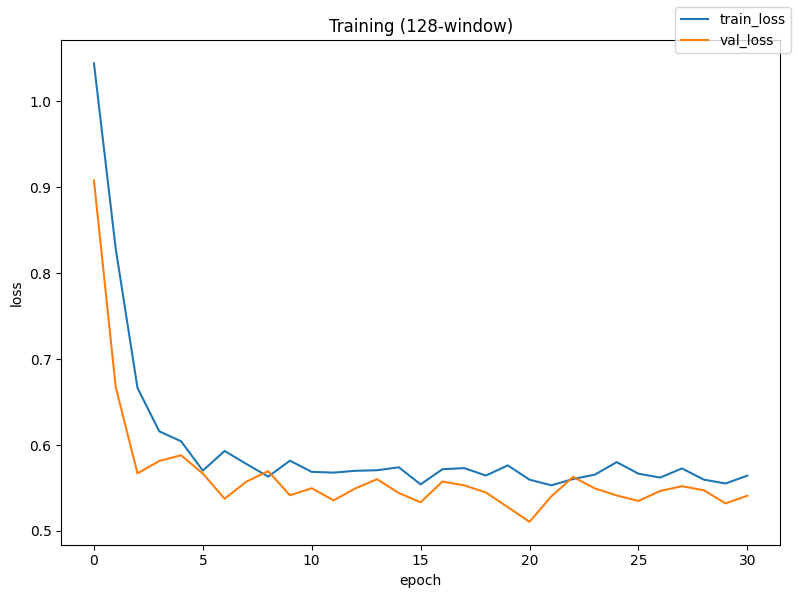

In [12]:
n_epochs = np.arange(0, len(train_result["train_loss"]))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_epochs, train_result["train_loss"], label="train_loss")
ax.plot(n_epochs, train_result["val_loss"], label="val_loss")
# ax.set_xticks(n_epochs)

ax.set_title("Training (128-window)")
ax.set_ylabel("loss")
ax.set_xlabel("epoch")
fig.legend()

plt.tight_layout()
plt.show()